In [1]:
import pandas as pd
x = pd.read_csv("/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv")
display(x)

,provider_name,provider_id,provider_type,provider_hq_country,effective_country,input_name,input_id,input_name_full,input_type,production_stage,stage_id,input_data_year,share_provided,provision_year,input_market_size,source
0,ACM Research,P313,organization,USA,USA,Wet etching and cleaning tools,N49,Wet etching and cleaning tools,tool_resource,NaN,NaN,2024.0,11.4,2024,$6.4 billion (2024),CSET analysis of TechInsights data (2024). Dat...
1,ACM Research,P313,organization,USA,USA,Etch and clean tools,N55,Etch and clean tools,tool_resource,NaN,NaN,2024.0,3.0,2024,$24.7 billion (2024),CSET analysis of TechInsights data (2024). Dat...
2,AMEC,P123,organization,CHN,CHN,Dry etching tools (adv. pkg.),N101,Dry etching tools (adv. pkg.),tool_resource,NaN,NaN,2024.0,18.1,2024,$831.6 million (2024),CSET analysis of TechInsights data (2024). Dat...
3,AMEC,P123,organization,CHN,CHN,Dry etch tools,N103,Dry etch tools,tool_resource,NaN,NaN,2024.0,5.5,2024,$18.5 billion (2024),CSET analysis of TechInsights data (2024). Dat...
4,AMEC,P123,organization,CHN,CHN,Fabrication tools (for advanced packaging),N109,Fabrication tools (for advanced packaging),tool_resource,NaN,NaN,2024.0,2.5,2024,$5.9 billion (2024),CSET analysis of TechInsights data (2024). Dat...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1300,Zhonghuan,P231,organization,CHN,CHN,Wafer,N26,Wafer,material_resource,NaN,NaN,2019.0,NaN,2019,$10.9 billion,[CSET](https://cset.georgetown.edu/publication...
1301,Zhongwei,P295,organization,CHN,CHN,Ceramic packages,N95,Ceramic packages,material_resource,NaN,NaN,NaN,NaN,2019,NaN,NaN
1302,Zhuhai Yueya,P301,organization,CHN,CHN,Substrates,N96,Substrates,material_resource,NaN,NaN,NaN,NaN,2019,NaN,NaN
1303,ZingSEMI,P237,organization,CHN,CHN,Wafer,N26,Wafer,material_resource,NaN,NaN,2019.0,NaN,2019,$10.9 billion,[CSET](https://cset.georgetown.edu/publication...


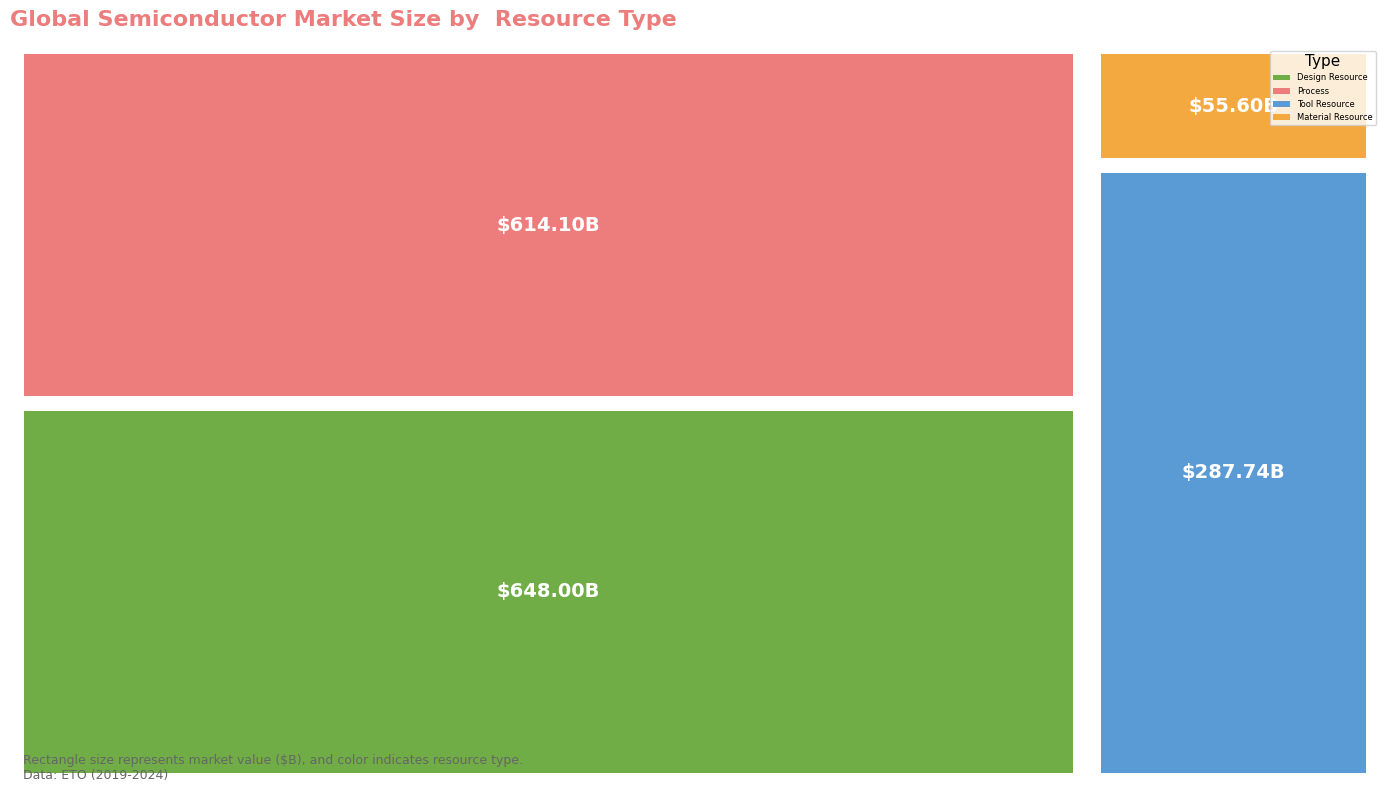

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import squarify

semi = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/output/semiconductor_master.csv')
inputs = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/Advanced Semiconductor/inputs.csv')

# Parse market size from string to numeric (trillions)
def parse_market_size(s):
    if pd.isna(s):
        return 0
    s = str(s).replace(',', '')
    for match in [s]:
        import re
        nums = re.findall(r'[\d.]+', match.replace('$', '').replace(',', ''))
        if nums:
            val = float(nums[0])
            if 'billion' in match.lower():
                return val  # convert to trillions
            elif 'million' in match.lower():
                return val / 1000
            elif 'trillion' in match.lower():
                return val * 1000
            else:
                return val / 1000  # assume billions
    return 0

inputs['market_size_T'] = inputs['market_share_chart_global_market_size_info'].apply(parse_market_size)

# Aggregate by type
type_market = inputs.groupby('type')['market_size_T'].sum().sort_values(ascending=False)

type_labels = {
    'tool_resource': 'Tool Resource', 'material_resource': 'Material Resource',
    'process': 'Process', 'design_resource': 'Design Resource', 'ultimate_output': 'Ultimate Output'
}
type_colors = {
    'tool_resource': '#5B9BD5', 'design_resource': '#70AD47',
    'process': '#ED7D7D', 'material_resource': '#F4A940', 'ultimate_output': '#A5A5A5'
}

# Filter out zero/tiny
type_market = type_market[type_market > 0.01]

labels = [f"${v:.2f}B" for v in type_market.values]
colors = [type_colors.get(t, '#999') for t in type_market.index]

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

squarify.plot(
    sizes=type_market.values, label=labels, color=colors,
    alpha=1.0, ax=ax, text_kwargs={'fontsize': 14, 'color': 'white', 'fontweight': 'bold'},
    pad=2
)

ax.set_title('Global Semiconductor Market Size by  Resource Type',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)
ax.axis('off')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=type_colors[k], label=type_labels[k])
                   for k in type_market.index if k in type_colors]
ax.legend(handles=legend_elements, loc='upper right', title='Type',
          fontsize=6, title_fontsize=11, frameon=True)

fig.text(0.02, 0.02, 'Rectangle size represents market value ($B), and color indicates resource type.\nData: ETO (2019-2024)',
         fontsize=9, color='#666')

plt.tight_layout()
plt.savefig('viz_semi_01_treemap.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
import re

ISO_TO_NAME = {
    'USA': 'United States', 'CHN': 'China', 'JPN': 'Japan', 'KOR': 'South Korea',
    'TWN': 'Taiwan', 'DEU': 'Germany', 'SGP': 'Singapore', 'GBR': 'United Kingdom',
    'NLD': 'Netherlands', 'FRA': 'France', 'ITA': 'Italy', 'CHE': 'Switzerland',
    'AUT': 'Austria', 'SWE': 'Sweden', 'ISR': 'Israel', 'FIN': 'Finland',
    'BEL': 'Belgium', 'MYS': 'Malaysia', 'IND': 'India', 'CAN': 'Canada',
    'BLR': 'Belarus', 'CZE': 'Czech Republic', 'HUN': 'Hungary',
}

def parse_market_size(s):
    if pd.isna(s):
        return 0
    s = str(s).replace(',', '')
    for match in [s]:
        import re
        nums = re.findall(r'[\d.]+', match.replace('$', '').replace(',', ''))
        if nums:
            val = float(nums[0])
            if 'billion' in match.lower():
                return val  # convert to trillions
            elif 'million' in match.lower():
                return val / 1000
            elif 'trillion' in match.lower():
                return val * 1000
            else:
                return val / 1000  # assume billions
    return 0

inputs['market_size_T'] = inputs['market_share_chart_global_market_size_info'].apply(parse_market_size)

# Prepare inputs with market size and renamed type column
inputs_with_market = inputs[['input_id', 'type', 'market_size_T']].copy()
inputs_with_market = inputs_with_market[inputs_with_market.market_size_T > 0]
inputs_with_market = inputs_with_market.rename(columns={'type': 'resource_type'})

# Merge semiconductor master with input market sizes
semi_with_market = semi.merge(
    inputs_with_market, left_on='input_id', right_on='input_id', how='inner'
)

# Filter to country-level providers with share data
semi_country = semi_with_market[
    (semi_with_market.provider_type == 'country') &
    (semi_with_market.share_provided.notna()) &
    (~semi_with_market.provider_name.str.contains('Various', case=False, na=False))
].copy()

semi_country['country_name'] = semi_country['provider_name'].map(ISO_TO_NAME).fillna(semi_country['provider_name'])
semi_country['market_value_T'] = semi_country['share_provided'] / 100 * semi_country['market_size_T']

# Pivot: country × resource_type
country_type = semi_country.groupby(['country_name', 'resource_type'])['market_value_T'].sum().reset_index()
ct_pivot = country_type.pivot_table(index='country_name', columns='resource_type', values='market_value_T', fill_value=0)
ct_pivot['total'] = ct_pivot.sum(axis=1)
ct_pivot = ct_pivot.sort_values('total', ascending=False).drop(columns='total')

display(ct_pivot)

resource_type,design_resource,material_resource,process,tool_resource
country_name,,,,
United States,109.817,3.628,373.165,129.592779
Japan,43.052,8.224,22.964,70.377382
South Korea,85.428,1.090,17.223,7.166446
EUR,32.079,0.000,51.669,0.000000
Taiwan,14.627,2.063,63.151,0.548954
China,20.877,0.514,28.705,15.634987
Netherlands,0.000,0.000,0.000,54.189272
Germany,0.000,1.526,0.000,1.860985
Singapore,0.000,0.000,0.000,3.157593


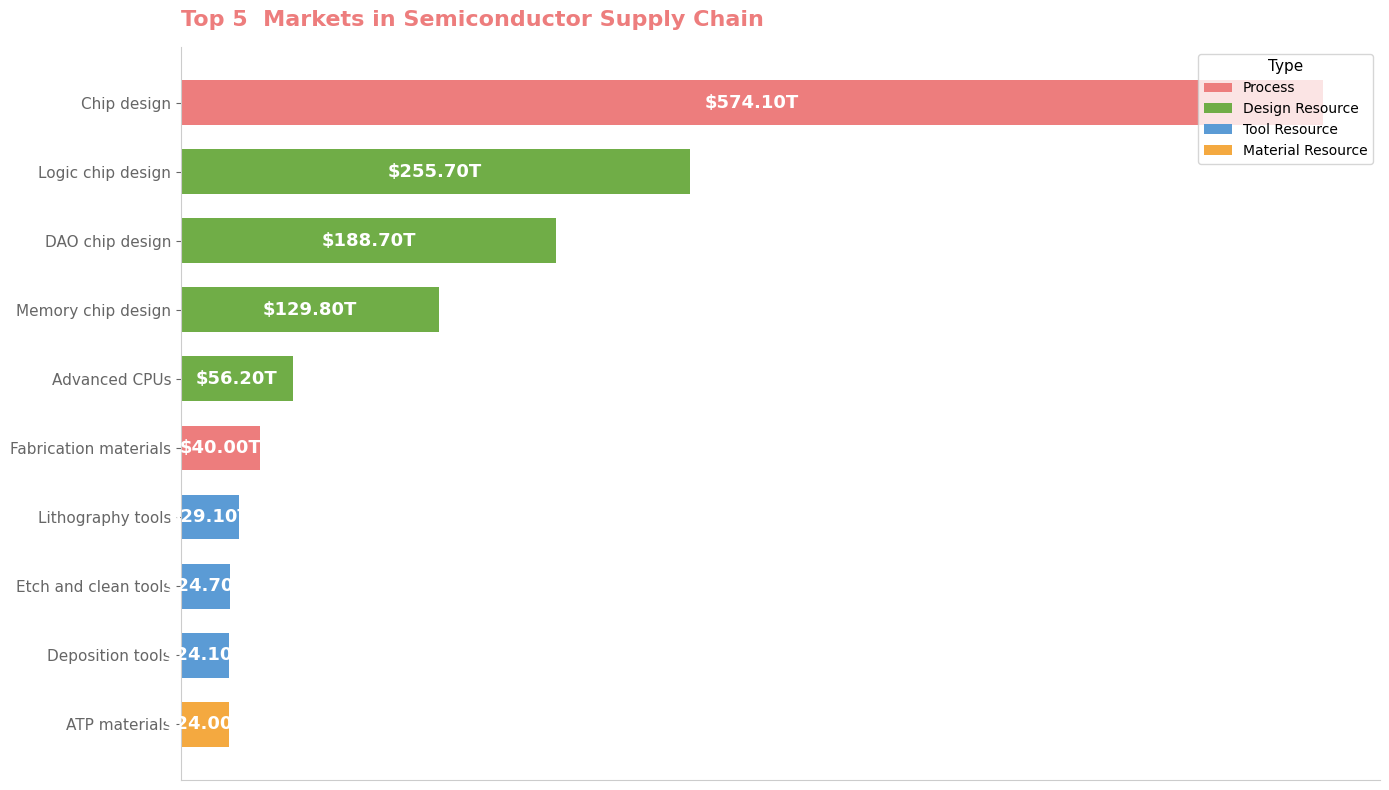

In [ ]:
# Top 5 inputs by market size
top5 = inputs[inputs.market_size_T > 0].nlargest(10, 'market_size_T')[
    ['input_name', 'type', 'market_size_T']
].copy()

type_colors_map = {
    'tool_resource': '#5B9BD5', 'design_resource': '#70AD47',
    'process': '#ED7D7D', 'material_resource': '#F4A940',
}

fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

y = np.arange(len(top5))
colors = [type_colors_map.get(t, '#999') for t in top5['type']]
bars = ax.barh(y, top5['market_size_T'], color=colors, height=0.65, edgecolor='none')

ax.set_yticks(y)
ax.set_yticklabels(top5['input_name'], fontsize=11, color='#333')
ax.invert_yaxis()

# Value labels inside bars
for bar, val in zip(bars, top5['market_size_T']):
    ax.text(bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
            f'${val:.2f}T', ha='center', va='center',
            fontsize=13, fontweight='bold', color='white')

ax.set_title('Top 10  Markets in Semiconductor Supply Chain',
             fontsize=16, fontweight='bold', color='#ED7D7D', loc='left', pad=15)

# Legend
present_types = top5['type'].unique()
legend_elements = [Patch(facecolor=type_colors_map[t], label=type_labels.get(t, t))
                   for t in present_types if t in type_colors_map]
ax.legend(handles=legend_elements, title='Type', loc='upper right', fontsize=10, title_fontsize=11)

ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#ccc'); ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#666')
ax.set_xlim(0, top5.market_size_T.max() * 1.05)
ax.xaxis.set_visible(False)

plt.tight_layout()
plt.savefig('viz_semi_03_top5_markets.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [19]:
import pandas as pd
import numpy as np

# Load data
semi = pd.read_csv('datasets/Advanced Semiconductor/output/semiconductor_master.csv')

# Filter: country-level, has share data, exclude 'Various'
country_data = semi[
    (semi.provider_type == 'country') &
    (semi.share_provided.notna()) &
    (~semi.provider_name.str.contains('Various', case=False, na=False))
].copy()

ISO_TO_NAME = {
    'USA': 'United States', 'CHN': 'China', 'JPN': 'Japan', 'KOR': 'South Korea',
    'TWN': 'Taiwan', 'DEU': 'Germany', 'SGP': 'Singapore', 'GBR': 'United Kingdom',
    'NLD': 'Netherlands', 'FRA': 'France', 'ITA': 'Italy', 'CHE': 'Switzerland',
    'AUT': 'Austria', 'SWE': 'Sweden', 'ISR': 'Israel', 'FIN': 'Finland',
    'BEL': 'Belgium', 'MYS': 'Malaysia', 'IND': 'India', 'CAN': 'Canada',
    'BLR': 'Belarus', 'CZE': 'Czech Republic', 'HUN': 'Hungary', 'EUR': 'Europe',
}
country_data['country_name'] = country_data['effective_country'].map(ISO_TO_NAME).fillna(country_data['effective_country'])

# ── Check what years we have ──
print("=== Years in provision data ===")
print(country_data['provision_year'].value_counts().sort_index())
print()

# ── Check inputs per year ──
print("=== Unique inputs per year ===")
for yr in sorted(country_data.provision_year.unique()):
    n_inputs = country_data[country_data.provision_year == yr].input_id.nunique()
    n_countries = country_data[country_data.provision_year == yr].country_name.nunique()
    print(f"  {yr}: {n_inputs} inputs, {n_countries} countries")
print()

# ── Method: For each year, compute each country's total share across all inputs ──
# Sum of (share_provided) per country per year, then normalize by total
yearly_shares = country_data.groupby(['provision_year', 'country_name'])['share_provided'].sum().reset_index()
year_totals = yearly_shares.groupby('provision_year')['share_provided'].sum().reset_index(name='year_total')
yearly_shares = yearly_shares.merge(year_totals, on='provision_year')
yearly_shares['country_pct'] = yearly_shares['share_provided'] / yearly_shares['year_total']

print("=== Country share of global semiconductor supply ===")
print(yearly_shares.sort_values(['provision_year', 'country_pct'], ascending=[True, False]).to_string(index=False))
print()

# ── Pivot for easier viewing ──
pivot = yearly_shares.pivot_table(
    index='country_name', columns='provision_year', values='country_pct', fill_value=0
)
pivot['latest'] = pivot[pivot.columns[-1]]
pivot = pivot.sort_values('latest', ascending=False)
print("=== Pivoted: Country × Year (as % of global) ===")
print((pivot * 100).round(2).to_string())
print()

# ── Top 10 countries by latest year ──
top10 = pivot.head(10).index.tolist()
print(f"Top 10 countries (by latest year): {top10}")

# ── Save for charting ──
chart_data = yearly_shares[yearly_shares.country_name.isin(top10)].copy()
chart_data = chart_data[['provision_year', 'country_name', 'country_pct']].sort_values(['country_name', 'provision_year'])
chart_data.to_csv('datasets/Advanced Semiconductor/output/country_share_over_time.csv', index=False)
print(f"\n✅ Saved: country_share_over_time.csv ({len(chart_data)} rows)")
print(chart_data.to_string(index=False))

=== Years in provision data ===
provision_year
2019     17
2022     36
2024    393
Name: count, dtype: int64

=== Unique inputs per year ===
  2019: 4 inputs, 8 countries
  2022: 7 inputs, 7 countries
  2024: 83 inputs, 18 countries

=== Country share of global semiconductor supply ===
 provision_year   country_name  share_provided  year_total  country_pct
           2019  United States           188.0       400.0     0.470000
           2019          Japan           112.0       400.0     0.280000
           2019 United Kingdom            44.0       400.0     0.110000
           2019         Taiwan            24.0       400.0     0.060000
           2019        Germany            14.0       400.0     0.035000
           2019    South Korea            10.0       400.0     0.025000
           2019          China             7.0       400.0     0.017500
           2019         Israel             1.0       400.0     0.002500
           2022  United States           195.0       660.0     0.

In [23]:
from IPython.core.display_functions import display
parat = pd.read_csv('/Users/shadowclone/Documents/aisi/datasets/parat_data/output/parat_master.csv')

# ══════════════════════════════════════════════════════════════
# CHART 1: Donut — Global AI Landscape by Country (AI Publications)
# ══════════════════════════════════════════════════════════════

country_pubs = parat.groupby('Country').agg(
    ai_pubs=('Publications: AI publications', 'sum'),
    ai_patents=('Patents: AI patents', 'sum'),
    granted_patents=('Patents: Granted AI patents', 'sum'),
    ai_workers=('Workforce: AI workers', 'sum'),
).reset_index().sort_values('ai_pubs', ascending=False)

# Top 6 + Others
top_n = 10
top = country_pubs.head(top_n).copy()
others = pd.DataFrame([{
    'Country': 'Others',
    'ai_pubs': country_pubs.iloc[top_n:]['ai_pubs'].sum(),
    'ai_patents': country_pubs.iloc[top_n:]['ai_patents'].sum(),
    'granted_patents': country_pubs.iloc[top_n:]['granted_patents'].sum(),
    'ai_workers': country_pubs.iloc[top_n:]['ai_workers'].sum(),
}])
donut_data = pd.concat([top, others], ignore_index=True)

display(donut_data)

,Country,ai_pubs,ai_patents,granted_patents,ai_workers
0,United States,57494,59088,33797,170061
1,China,22665,48660,22286,5342
2,Japan,7325,11914,6029,592
3,Germany,5154,8407,2970,2772
4,South Korea,3140,8315,3248,875
5,Netherlands,1471,1688,595,779
6,Finland,967,1298,319,482
7,Switzerland,945,639,186,2264
8,United Kingdom,882,345,227,14487
9,Ireland,623,1141,613,14807


In [25]:
top_n_companies = 15
top_research = parat.nlargest(top_n_companies, 'Publications: AI publications').copy()

display(top_research)

,Name,ID,Country,Website,Groups,Aggregated subsidiaries,Region,Stage,Sector,Description,...,num_tickers,num_id_types,id_types,is_public,is_sp500,is_big_tech,is_genai,ai_pub_intensity,ai_patent_intensity,ai_worker_ratio
5,Alphabet (including Google),796,United States,https://abc.xyz/,"S&P 500, Global Big Tech","Waymo, Google, Deepmind",North America,Mature,Software & IT Services,Alphabet is a holding company that provides pr...,...,2,6,Crunchbase URL;Crunchbase UUID;GRID;LinkedIn;P...,True,True,True,False,52.756524,25.914287,0.066076
4,Microsoft,163,United States,http://www.microsoft.com,"S&P 500, Global Big Tech, GenAI Contenders",NaN,North America,Mature,Software & IT Services,Microsoft is a software corporation that devel...,...,2,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,True,True,True,True,45.500506,20.602531,0.051528
3,IBM,115,United States,http://www.ibm.com/,"S&P 500, Global Big Tech",NaN,North America,Mature,Software & IT Services,IBM is an IT technology and consulting firm pr...,...,1,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,True,True,True,False,29.382707,21.060813,0.054102
21,Huawei,112,China,https://www.huawei.com/,Global Big Tech,NaN,Asia,Mature,Technology Equipment,Huawei Technologies provides infrastructure ap...,...,0,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,False,False,True,False,31.342518,6.140993,0.049093
64,Tencent,245,China,https://www.tencent.com/,"Global Big Tech, GenAI Contenders",NaN,Asia,Mature,Software & IT Services,Tencent is an internet service portal offering...,...,1,6,Crunchbase URL;Crunchbase UUID;GRID;LinkedIn;P...,True,False,True,True,73.290530,23.136247,0.156419
165,Alibaba,21,China,http://alibabagroup.com,"Global Big Tech, GenAI Contenders",NaN,Asia,Mature,Software & IT Services,Alibaba Group enables businesses to transform ...,...,2,6,Crunchbase URL;Crunchbase UUID;GRID;LinkedIn;P...,True,False,True,True,65.273709,8.316626,0.194484
2,Amazon,23,United States,http://amazon.com,"S&P 500, Global Big Tech","Amazon Advertising, Amazon Web Services",North America,Mature,Retailers,Amazon is a global tech firm with a focus on e...,...,1,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,True,True,True,False,57.275189,17.617422,0.111891
27,Meta,87,United States,http://www.facebook.com,"S&P 500, Global Big Tech, GenAI Contenders",NaN,North America,Mature,Software & IT Services,Meta is a social technology company that enabl...,...,1,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,True,True,True,True,55.046948,12.547882,0.142911
39,Samsung,671,South Korea,https://www.samsung.com/,NaN,NaN,Asia,Mature,Technology Equipment,Samsung Electronics is an electronics company ...,...,0,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,False,False,False,False,20.434186,6.108025,0.063323
28,Adobe,6,United States,http://www.adobe.com,"S&P 500, Global Big Tech, GenAI Contenders",NaN,North America,Mature,Software & IT Services,Adobe is a software company that provides its ...,...,1,7,BGOV;Crunchbase URL;Crunchbase UUID;GRID;Linke...,True,True,True,True,71.075365,45.758355,0.079338


In [27]:
import pandas as pd
import numpy as np
import json

parat = pd.read_csv('datasets/parat_data/output/parat_master.csv')

# Filter to companies with any AI publications or citations
active = parat[
    (parat['Publications: AI publications'] > 0) | 
    (parat['Publications: Citations to AI research'] > 0)
].copy()

print(f'Total companies: {len(parat)}')
print(f'Active (pubs or citations > 0): {len(active)}')

# Compute log values
active['log_pubs'] = np.log1p(active['Publications: AI publications']).round(3)
active['log_cit'] = np.log1p(active['Publications: Citations to AI research']).round(3)

# Identify top 20 by combined log score (pubs + citations)
active['combined_score'] = active['log_pubs'] + active['log_cit']
top20_ids = active.nlargest(20, 'combined_score')['ID'].tolist()
active['is_top20'] = active['ID'].isin(top20_ids)

# GenAI flag
active['is_genai'] = active['is_genai'].fillna(False).astype(bool)

# Select columns for export
cols = [
    'Name', 'Country', 'log_pubs', 'log_cit',
    'Publications: AI publications',
    'Publications: Citations to AI research',
    'Patents: AI patents',
    'is_genai', 'is_top20'
]
export = active[cols].copy()

# Preview top 20
print(f'\n=== TOP 20 (will be labeled in chart) ===')
top20 = export[export.is_top20].sort_values('log_pubs', ascending=False)
for _, row in top20.iterrows():
    genai_flag = ' ★ GenAI' if row.is_genai else ''
    print(f"  {row.Name:35s} | {row.Country:15s} | pubs={row['Publications: AI publications']:>6,} | "
          f"cit={row['Publications: Citations to AI research']:>10,} | "
          f"log({row.log_pubs:.1f}, {row.log_cit:.1f}){genai_flag}")

# Stats
print(f'\n=== SUMMARY ===')
print(f'Total for export: {len(export)}')
print(f'Top 20 labeled: {export.is_top20.sum()}')
print(f'GenAI contenders: {export.is_genai.sum()}')
print(f'Overlap (top20 + genai): {((export.is_top20) & (export.is_genai)).sum()}')

# Save JSON
records = export.to_dict('records')
with open('datasets/parat_data/output/parat_scatter_data.json', 'w') as f:
    json.dump(records, f, indent=2)
print(f'\n✅ Saved: parat_scatter_data.json ({len(records)} companies)')

# Save CSV too
export.to_csv('datasets/parat_data/output/parat_scatter_data.csv', index=False)
print(f'✅ Saved: parat_scatter_data.csv')

Total companies: 691
Active (pubs or citations > 0): 451

=== TOP 20 (will be labeled in chart) ===
  Alphabet (including Google)         | United States   | pubs=10,067 | cit= 1,174,586 | log(9.2, 14.0)
  Microsoft                           | United States   | pubs= 9,900 | cit=   902,230 | log(9.2, 13.7) ★ GenAI
  IBM                                 | United States   | pubs= 8,030 | cit=   340,174 | log(9.0, 12.7)
  Huawei                              | China           | pubs= 4,891 | cit=   163,117 | log(8.5, 12.0)
  Tencent                             | China           | pubs= 4,566 | cit=   196,259 | log(8.4, 12.2) ★ GenAI
  Alibaba                             | China           | pubs= 4,233 | cit=   157,365 | log(8.4, 12.0) ★ GenAI
  Amazon                              | United States   | pubs= 4,019 | cit=   146,538 | log(8.3, 11.9)
  Meta                                | United States   | pubs= 3,283 | cit=   406,572 | log(8.1, 12.9) ★ GenAI
  Samsung                           

In [5]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#0D1117',
    'text.color': '#C9D1D9', 'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E', 'ytick.color': '#8B949E',
    'axes.edgecolor': '#21262D', 'grid.color': '#21262D', 'grid.alpha': 0.6,
    'font.family': 'sans-serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.titleweight': 'bold', 'axes.titlepad': 15,
    'figure.dpi': 120,
})

C = {
    'accent': '#58A6FF', 'accent2': '#3FB950', 'accent3': '#D29922',
    'accent4': '#F778BA', 'accent5': '#BC8CFF', 'danger': '#F85149',
    'muted': '#484F58', 'bg': '#0D1117', 'surface': '#161B22',
    'border': '#21262D', 'text': '#C9D1D9', 'text_dim': '#8B949E',
    'cyan': '#39D2C0', 'orange': '#F97316',
}
FIELD_COLORS = {
    'Artificial intelligence': '#58A6FF',
    'Computer vision': '#3FB950',
    'Chip design and fabrication': '#F85149',
    'Natural language processing': '#D29922',
    'Cybersecurity': '#BC8CFF',
    'Robotics': '#F778BA',
    'AI safety': '#39D2C0',
    'Large language models': '#F97316',
}
print('Setup complete ✓')

collab = pd.read_csv("/Users/shadowclone/Documents/aisi/datasets/country_research_collaborations/output/crossborder_collab_master.csv")

Setup complete ✓


In [11]:
import pandas as pd
import numpy as np
import json

df = pd.read_csv('datasets/country_research_collaborations/output/crossborder_collab_master.csv')
complete = df[df.complete == True].copy()

# ══════════════════════════════════════════════════════════════
# CHART 1: Chord Diagram — Top 15 countries, pairwise volumes
# ══════════════════════════════════════════════════════════════

# Get top 15 countries by total volume
country_vol = {}
for _, row in complete.iterrows():
    for c in [row.country1, row.country2]:
        country_vol[c] = country_vol.get(c, 0) + row.num_articles

top15 = sorted(country_vol.items(), key=lambda x: -x[1])[:15]
top15_names = [c for c, _ in top15]

# Pairwise matrix for top 15
pair_data = complete[
    (complete.country1.isin(top15_names)) & 
    (complete.country2.isin(top15_names))
]

# Deduplicate: only keep pairs where country1 < country2 alphabetically
pair_totals = pair_data.groupby(['country1', 'country2'])['num_articles'].sum().reset_index()
pair_totals['pair'] = pair_totals.apply(lambda r: tuple(sorted([r.country1, r.country2])), axis=1)
pair_dedup = pair_totals.groupby('pair')['num_articles'].sum().reset_index()
pair_dedup['source'] = pair_dedup.pair.apply(lambda x: x[0])
pair_dedup['target'] = pair_dedup.pair.apply(lambda x: x[1])
pair_dedup = pair_dedup.sort_values('num_articles', ascending=False)

chord_data = {
    'countries': [{'name': c, 'total': v} for c, v in top15],
    'links': [
        {'source': row.source, 'target': row.target, 'value': int(row.num_articles)}
        for _, row in pair_dedup.head(50).iterrows()
    ]
}

with open('datasets/country_research_collaborations/output/chord_data.json', 'w') as f:
    json.dump(chord_data, f, indent=2)
print(f'✅ Chart 1 — Chord: {len(chord_data["countries"])} countries, {len(chord_data["links"])} links')
print(f'   Top pair: {chord_data["links"][0]["source"]} ↔ {chord_data["links"][0]["target"]}: {chord_data["links"][0]["value"]:,}')

# ══════════════════════════════════════════════════════════════
# CHART 2: Stacked Area — Global volume by field (2015-2023)
# ══════════════════════════════════════════════════════════════

# Deduplicate: each pair counted once (use country1 < country2)
complete['pair_key'] = complete.apply(lambda r: '|'.join(sorted([r.country1, r.country2])), axis=1)
dedup = complete.drop_duplicates(subset=['pair_key', 'field', 'year'])

field_yearly = dedup.groupby(['year', 'field'])['num_articles'].sum().reset_index()
field_yearly = field_yearly.sort_values(['year', 'field'])

area_data = field_yearly.to_dict('records')

with open('datasets/country_research_collaborations/output/field_growth_data.json', 'w') as f:
    json.dump(area_data, f, indent=2)
print(f'\n✅ Chart 2 — Stacked Area: {len(area_data)} rows ({field_yearly.year.nunique()} years × {field_yearly.field.nunique()} fields)')
print(f'   2015 total: {field_yearly[field_yearly.year == 2015].num_articles.sum():,}')
print(f'   2023 total: {field_yearly[field_yearly.year == 2023].num_articles.sum():,}')

# ══════════════════════════════════════════════════════════════
# CHART 3: US-China collaboration by field over time
# ══════════════════════════════════════════════════════════════

us_china = complete[
    ((complete.country1 == 'United States') & (complete.country2 == 'China')) |
    ((complete.country1 == 'China') & (complete.country2 == 'United States'))
]
# Deduplicate
us_china_dedup = us_china.drop_duplicates(subset=['pair_key', 'field', 'year'])
uc_yearly = us_china_dedup.groupby(['year', 'field'])['num_articles'].sum().reset_index()
uc_yearly = uc_yearly.sort_values(['year', 'field'])

uc_data = uc_yearly.to_dict('records')

with open('datasets/country_research_collaborations/output/us_china_collab_data.json', 'w') as f:
    json.dump(uc_data, f, indent=2)
print(f'\n✅ Chart 3 — US-China: {len(uc_data)} rows')
print(f'   Peak year: {uc_yearly.groupby("year")["num_articles"].sum().idxmax()} ({uc_yearly.groupby("year")["num_articles"].sum().max():,})')

# ══════════════════════════════════════════════════════════════
# CHART 4: Partner Diversity Scatter
# ══════════════════════════════════════════════════════════════

partners = {}
volumes = {}
field_counts = {}
for _, row in complete.iterrows():
    for c in [row.country1, row.country2]:
        partners.setdefault(c, set()).add(row.country2 if c == row.country1 else row.country1)
        volumes[c] = volumes.get(c, 0) + row.num_articles
        field_counts.setdefault(c, set()).add(row.field)

scatter_records = []
for country in partners:
    scatter_records.append({
        'country': country,
        'n_partners': len(partners[country]),
        'total_volume': volumes.get(country, 0),
        'n_fields': len(field_counts.get(country, set())),
        'avg_per_partner': round(volumes.get(country, 0) / max(len(partners[country]), 1)),
    })

scatter_df = pd.DataFrame(scatter_records).sort_values('total_volume', ascending=False)

# Flag top 15 for labeling
scatter_df['is_top15'] = scatter_df.index.isin(scatter_df.head(15).index)

scatter_data = scatter_df.to_dict('records')

with open('datasets/country_research_collaborations/output/partner_diversity_data.json', 'w') as f:
    json.dump(scatter_data, f, indent=2)
print(f'\n✅ Chart 4 — Partner Diversity: {len(scatter_data)} countries')
print(f'   Most connected: {scatter_df.iloc[0]["country"]} ({scatter_df.iloc[0]["n_partners"]} partners)')
print(f'   Highest volume: {scatter_df.iloc[0]["country"]} ({scatter_df.iloc[0]["total_volume"]:,} articles)')

# ══════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════
print(f'\n{"="*60}')
print(f'ALL 4 DATASETS EXPORTED:')
print(f'  1. chord_data.json          — Chord diagram (top 15 countries)')
print(f'  2. field_growth_data.json   — Stacked area (8 fields × 9 years)')
print(f'  3. us_china_collab_data.json — US-China by field over time')
print(f'  4. partner_diversity_data.json — Scatter (94 countries)')
print(f'{"="*60}')

✅ Chart 1 — Chord: 15 countries, 50 links
   Top pair: China ↔ United States: 162,646

✅ Chart 2 — Stacked Area: 70 rows (9 years × 8 fields)
   2015 total: 39,442
   2023 total: 174,138

✅ Chart 3 — US-China: 69 rows
   Peak year: 2021 (12,546)

✅ Chart 4 — Partner Diversity: 89 countries
   Most connected: United States (73 partners)
   Highest volume: United States (582,270 articles)

ALL 4 DATASETS EXPORTED:
  1. chord_data.json          — Chord diagram (top 15 countries)
  2. field_growth_data.json   — Stacked area (8 fields × 9 years)
  3. us_china_collab_data.json — US-China by field over time
  4. partner_diversity_data.json — Scatter (94 countries)


In [12]:
import pandas as pd
import numpy as np
import re
from collections import Counter

df = pd.read_csv('datasets/agora/output/agora_master.csv')
print(f'Total documents: {len(df)}')
print(f'Columns with summaries: Short summary={df["Short summary"].notna().sum()}, Long summary={df["Long summary"].notna().sum()}')

# ══════════════════════════════════════════════════════════════
# SIGNAL 1: Tag-based classification
# ══════════════════════════════════════════════════════════════

ENABLING_TAGS = [
    'Strategies: Government support',
    'Strategies: Government support: For R&D',
    'Strategies: Government support: AI workforce-related',
    'Strategies: Pilots and testbeds',
    'Strategies: New institution',
    'Incentives: Access to business opportunities',
    'Incentives: Subsidies',
]

RESTRICTIVE_TAGS = [
    'Incentives: Criminal liability',
    'Incentives: Civil liability',
    'Incentives: Fines',
    'Incentives: Imprisonment',
    'Strategies: Input controls',
    'Strategies: Input controls: Compute circulation',
    'Strategies: Input controls: Compute use',
    'Strategies: Input controls: Data circulation',
    'Strategies: Input controls: Data use',
    'Strategies: Licensing, registration, and certification',
    'Strategies: Performance requirements',
]

NEUTRAL_TAGS = [
    'Strategies: Government study or report',
    'Strategies: Convening',
    'Strategies: Governance development',
    'Strategies: Disclosure',
    'Strategies: Evaluation',
    'Strategies: Evaluation: Impact assessment',
    'Strategies: Evaluation: External auditing',
    'Strategies: Evaluation: Post-market monitoring',
    'Strategies: Tiering',
]

def count_tags(row, tag_list):
    count = 0
    for tag in tag_list:
        if tag in df.columns:
            val = str(row.get(tag, '')).strip().upper()
            if val in ('TRUE', '1'):
                count += 1
    return count

df['enabling_tag_count'] = df.apply(lambda r: count_tags(r, ENABLING_TAGS), axis=1)
df['restrictive_tag_count'] = df.apply(lambda r: count_tags(r, RESTRICTIVE_TAGS), axis=1)
df['neutral_tag_count'] = df.apply(lambda r: count_tags(r, NEUTRAL_TAGS), axis=1)

print(f'\n=== TAG SIGNAL DISTRIBUTION ===')
print(f'Docs with enabling tags:    {(df.enabling_tag_count > 0).sum()}')
print(f'Docs with restrictive tags: {(df.restrictive_tag_count > 0).sum()}')
print(f'Docs with neutral tags:     {(df.neutral_tag_count > 0).sum()}')
print(f'Docs with no signal tags:   {((df.enabling_tag_count == 0) & (df.restrictive_tag_count == 0) & (df.neutral_tag_count == 0)).sum()}')

# ══════════════════════════════════════════════════════════════
# SIGNAL 2: Keyword analysis on summaries
# ══════════════════════════════════════════════════════════════

ENABLING_KEYWORDS = [
    'promote', 'promote', 'support', 'fund', 'funding', 'invest', 'incentive',
    'accelerate', 'encourage', 'foster', 'advance', 'develop', 'innovation',
    'research and development', 'r&d', 'grant', 'subsidy', 'subsidize',
    'workforce', 'talent', 'training', 'scholarship', 'pilot', 'testbed',
    'sandbox', 'partnership', 'collaboration', 'competitiveness', 'leadership',
    'establish', 'create', 'launch', 'initiative', 'strategy', 'roadmap',
    'task force', 'advisory', 'coordinate', 'modernize', 'upgrade',
    'national ai', 'ai strategy', 'adopt', 'deployment', 'facilitate',
]

RESTRICTIVE_KEYWORDS = [
    'prohibit', 'ban', 'restrict', 'regulate', 'penalty', 'fine', 'liable',
    'liability', 'enforce', 'compliance', 'obligation', 'require', 'mandate',
    'moratorium', 'suspend', 'limit', 'constrain', 'control', 'oversight',
    'audit', 'certif', 'license', 'registration', 'approval', 'consent',
    'impact assessment', 'risk assessment', 'forbidden', 'unlawful', 'illegal',
    'criminal', 'imprisonment', 'sanction', 'punish', 'violation', 'enforce',
    'discriminat', 'bias', 'surveillance', 'deepfake', 'harmful',
    'transparency requirement', 'disclosure requirement', 'notify',
]

NEUTRAL_KEYWORDS = [
    'study', 'report', 'assess', 'review', 'examine', 'evaluate', 'analyze',
    'recommend', 'convene', 'commission', 'committee', 'working group',
    'framework', 'guideline', 'standard', 'principle', 'best practice',
    'voluntary', 'non-binding', 'guidance', 'definition', 'classify',
    'inventory', 'catalogue', 'monitor', 'track', 'measure',
]

def keyword_score(text, keywords):
    if pd.isna(text):
        return 0
    text = str(text).lower()
    score = 0
    for kw in keywords:
        score += len(re.findall(r'\b' + re.escape(kw), text))
    return score

# Combine short + long summary
df['full_text'] = df['Short summary'].fillna('') + ' ' + df['Long summary'].fillna('')

df['enabling_kw_score'] = df['full_text'].apply(lambda t: keyword_score(t, ENABLING_KEYWORDS))
df['restrictive_kw_score'] = df['full_text'].apply(lambda t: keyword_score(t, RESTRICTIVE_KEYWORDS))
df['neutral_kw_score'] = df['full_text'].apply(lambda t: keyword_score(t, NEUTRAL_KEYWORDS))

print(f'\n=== KEYWORD SIGNAL DISTRIBUTION ===')
print(f'Docs with enabling keywords:    {(df.enabling_kw_score > 0).sum()}')
print(f'Docs with restrictive keywords: {(df.restrictive_kw_score > 0).sum()}')
print(f'Docs with neutral keywords:     {(df.neutral_kw_score > 0).sum()}')

# ══════════════════════════════════════════════════════════════
# COMBINED CLASSIFICATION
# ══════════════════════════════════════════════════════════════

# Normalize: tag scores weighted 2x (human-curated), keyword scores 1x
df['enabling_score'] = df['enabling_tag_count'] * 2 + df['enabling_kw_score']
df['restrictive_score'] = df['restrictive_tag_count'] * 2 + df['restrictive_kw_score']
df['neutral_score'] = df['neutral_tag_count'] * 2 + df['neutral_kw_score']

def classify(row):
    scores = {
        'Enabling': row['enabling_score'],
        'Restrictive': row['restrictive_score'],
        'Neutral': row['neutral_score'],
    }
    max_score = max(scores.values())
    if max_score == 0:
        return 'Unclassified'
    
    # If enabling and restrictive are close (within 30%), call it "Balanced"
    if scores['Enabling'] > 0 and scores['Restrictive'] > 0:
        ratio = min(scores['Enabling'], scores['Restrictive']) / max(scores['Enabling'], scores['Restrictive'])
        if ratio > 0.7:
            return 'Balanced'
    
    return max(scores, key=scores.get)

df['policy_stance'] = df.apply(classify, axis=1)

print(f'\n=== FINAL CLASSIFICATION ===')
print(df['policy_stance'].value_counts().to_string())

print(f'\n=== BY JURISDICTION ===')
ct = pd.crosstab(df['Jurisdiction'], df['policy_stance'])
print(ct.to_string())

print(f'\n=== BY STATUS ===')
ct2 = pd.crosstab(df['Most recent activity'], df['policy_stance'])
print(ct2.to_string())

# ══════════════════════════════════════════════════════════════
# YEARLY TRENDS
# ══════════════════════════════════════════════════════════════

if 'activity_year' in df.columns:
    yearly_stance = pd.crosstab(df['activity_year'], df['policy_stance'])
    print(f'\n=== YEARLY STANCE TRENDS ===')
    print(yearly_stance.to_string())

# ══════════════════════════════════════════════════════════════
# BY AUTHORITY (top 15)
# ══════════════════════════════════════════════════════════════

top_auth = df['Authority'].value_counts().head(15).index
auth_stance = pd.crosstab(df[df.Authority.isin(top_auth)]['Authority'], 
                           df[df.Authority.isin(top_auth)]['policy_stance'])
print(f'\n=== TOP 15 AUTHORITIES BY STANCE ===')
print(auth_stance.to_string())

# ══════════════════════════════════════════════════════════════
# SAMPLE VALIDATION — check a few classifications
# ══════════════════════════════════════════════════════════════

print(f'\n=== SAMPLE: Enabling policies ===')
enabling = df[df.policy_stance == 'Enabling'].nlargest(5, 'enabling_score')
for _, row in enabling.iterrows():
    summary = str(row['Short summary'])[:120] if pd.notna(row['Short summary']) else 'No summary'
    print(f'  [{row["Most recent activity"]:8s}] {row["Casual name"] if pd.notna(row.get("Casual name")) else row["Official name"][:50]}')
    print(f'    → {summary}...')

print(f'\n=== SAMPLE: Restrictive policies ===')
restrictive = df[df.policy_stance == 'Restrictive'].nlargest(5, 'restrictive_score')
for _, row in restrictive.iterrows():
    summary = str(row['Short summary'])[:120] if pd.notna(row['Short summary']) else 'No summary'
    print(f'  [{row["Most recent activity"]:8s}] {row["Casual name"] if pd.notna(row.get("Casual name")) else row["Official name"][:50]}')
    print(f'    → {summary}...')

print(f'\n=== SAMPLE: Balanced policies ===')
balanced = df[df.policy_stance == 'Balanced'].nlargest(5, 'enabling_score')
for _, row in balanced.iterrows():
    summary = str(row['Short summary'])[:120] if pd.notna(row['Short summary']) else 'No summary'
    print(f'  [{row["Most recent activity"]:8s}] {row["Casual name"] if pd.notna(row.get("Casual name")) else row["Official name"][:50]}')
    print(f'    → {summary}...')

# ══════════════════════════════════════════════════════════════
# SAVE
# ══════════════════════════════════════════════════════════════

export_cols = [
    'AGORA ID', 'Official name', 'Casual name', 'Authority', 'Jurisdiction',
    'Most recent activity', 'activity_year', 'proposed_year',
    'policy_stance', 'enabling_score', 'restrictive_score', 'neutral_score',
    'enabling_tag_count', 'restrictive_tag_count', 'neutral_tag_count',
    'enabling_kw_score', 'restrictive_kw_score', 'neutral_kw_score',
    'num_tags', 'num_applications_tags', 'num_harms_tags',
    'num_incentives_tags', 'num_risk_factors_tags', 'num_strategies_tags',
]
export_cols = [c for c in export_cols if c in df.columns]

df[export_cols].to_csv('datasets/agora/output/agora_classified.csv', index=False)
print(f'\n✅ Saved: agora_classified.csv ({len(df)} docs)')

Total documents: 973
Columns with summaries: Short summary=968, Long summary=969

=== TAG SIGNAL DISTRIBUTION ===
Docs with enabling tags:    290
Docs with restrictive tags: 192
Docs with neutral tags:     451
Docs with no signal tags:   469

=== KEYWORD SIGNAL DISTRIBUTION ===
Docs with enabling keywords:    846
Docs with restrictive keywords: 902
Docs with neutral keywords:     802

=== FINAL CLASSIFICATION ===
policy_stance
Enabling        346
Restrictive     293
Neutral         191
Balanced        137
Unclassified      6

=== BY JURISDICTION ===
policy_stance    Balanced  Enabling  Neutral  Restrictive  Unclassified
Jurisdiction                                                           
China                   5         9        5            7             0
Multinational           3        10        3            3             1
Other countries         1         7        4            6             0
United States         120       311      171          275             5

=== BY STAT

In [13]:
import pandas as pd
import numpy as np
import json

pubs = pd.read_csv('datasets/Country AI activity/output/country_ai_publications_master.csv')
patents = pd.read_csv('datasets/Country AI activity/output/country_ai_patents_master.csv')
invest = pd.read_csv('datasets/Country AI activity/output/country_ai_investment_master.csv')

# Exclude group entities
pubs = pubs[pubs.is_group == False].copy()
patents = patents[patents.is_group == False].copy()
invest = invest[invest.is_group == False].copy()

# Harmonize China
for df in [pubs, patents, invest]:
    df['country'] = df['country'].replace('China (mainland)', 'China')

# ══════════════════════════════════════════════════════════════
# CHART 1: Racing Bar — Publications over time (top 15)
# ══════════════════════════════════════════════════════════════

pub_all = pubs[(pubs.field == 'All') & (pubs.complete == True)].copy()
top15_countries = pub_all.groupby('country')['num_articles'].sum().nlargest(15).index.tolist()

racing_data = pub_all[pub_all.country.isin(top15_countries)][['country', 'year', 'num_articles']].copy()
racing_data = racing_data.sort_values(['year', 'num_articles'], ascending=[True, False])

print('=== CHART 1: RACING BAR ===')
print(f'Countries: {top15_countries}')
print(f'Years: {sorted(racing_data.year.unique())}')
print(f'Rows: {len(racing_data)}')

# Preview — rank per year
for yr in sorted(racing_data.year.unique()):
    top3 = racing_data[racing_data.year == yr].head(3)
    vals = ', '.join([f'{r.country}: {r.num_articles:,.0f}' for _, r in top3.iterrows()])
    print(f'  {yr}: {vals}')

racing_data.to_json('datasets/Country AI activity/output/racing_bar_data.json', orient='records', indent=2)
print(f'✅ Saved: racing_bar_data.json')

# ══════════════════════════════════════════════════════════════
# CHART 2: Heatmap — Investment by country × sector
# ══════════════════════════════════════════════════════════════

inv_all = invest[(invest.field != 'All') & (invest.complete == True)].copy()

# Top 15 countries by total investment
top15_inv = inv_all.groupby('country')['estimated_investment'].sum().nlargest(15).index.tolist()

# Top 15 sectors by total investment
top15_sectors = inv_all.groupby('field')['estimated_investment'].sum().nlargest(15).index.tolist()

heatmap_raw = inv_all[
    (inv_all.country.isin(top15_inv)) & (inv_all.field.isin(top15_sectors))
].groupby(['country', 'field'])['estimated_investment'].sum().reset_index()

# Also compute log for better color scaling
heatmap_raw['log_investment'] = np.log1p(heatmap_raw['estimated_investment']).round(2)

print(f'\n=== CHART 2: HEATMAP ===')
print(f'Countries: {top15_inv}')
print(f'Sectors: {top15_sectors}')
print(f'Rows: {len(heatmap_raw)}')

# Pivot preview
pivot = heatmap_raw.pivot_table(index='country', columns='field', values='estimated_investment', fill_value=0)
print(f'\nTop 5 countries × Top 5 sectors ($M):')
top5c = pivot.sum(axis=1).nlargest(5).index
top5s = pivot.sum(axis=0).nlargest(5).index
print(pivot.loc[top5c, top5s].round(0).to_string())

heatmap_raw.to_json('datasets/Country AI activity/output/heatmap_data.json', orient='records', indent=2)
print(f'✅ Saved: heatmap_data.json')

# ══════════════════════════════════════════════════════════════
# CHART 3: Sunburst — Patents by region → country → field
# ══════════════════════════════════════════════════════════════

pat_fields = patents[(patents.field != 'All') & (patents.complete == True)].copy()

# Region mapping
REGION_MAP = {
    'United States': 'Americas', 'Canada': 'Americas', 'Brazil': 'Americas',
    'Argentina': 'Americas', 'Mexico': 'Americas', 'Chile': 'Americas',
    'Colombia': 'Americas',
    'China': 'Asia-Pacific', 'Japan': 'Asia-Pacific', 'South Korea': 'Asia-Pacific',
    'India': 'Asia-Pacific', 'Taiwan': 'Asia-Pacific', 'Singapore': 'Asia-Pacific',
    'Australia': 'Asia-Pacific', 'Malaysia': 'Asia-Pacific', 'Thailand': 'Asia-Pacific',
    'New Zealand': 'Asia-Pacific', 'Indonesia': 'Asia-Pacific',
    'United Kingdom': 'Europe', 'Germany': 'Europe', 'France': 'Europe',
    'Italy': 'Europe', 'Netherlands': 'Europe', 'Spain': 'Europe',
    'Switzerland': 'Europe', 'Sweden': 'Europe', 'Denmark': 'Europe',
    'Belgium': 'Europe', 'Austria': 'Europe', 'Finland': 'Europe',
    'Norway': 'Europe', 'Ireland': 'Europe', 'Poland': 'Europe',
    'Russia': 'Europe', 'Turkey': 'Europe',
    'Israel': 'Middle East & Africa', 'Saudi Arabia': 'Middle East & Africa',
    'South Africa': 'Middle East & Africa', 'Iran': 'Middle East & Africa',
    'Egypt': 'Middle East & Africa',
}

pat_fields['region'] = pat_fields['country'].map(REGION_MAP).fillna('Other')

# Top 12 countries by total patents
top12_pat = pat_fields.groupby('country')['num_patent_applications'].sum().nlargest(12).index.tolist()
pat_filtered = pat_fields[pat_fields.country.isin(top12_pat)]

# Build hierarchy: region → country → field
sunburst_records = []
for region in pat_filtered.region.unique():
    region_df = pat_filtered[pat_filtered.region == region]
    region_total = region_df.num_patent_applications.sum()
    
    for country in region_df.country.unique():
        country_df = region_df[region_df.country == country]
        country_total = country_df.num_patent_applications.sum()
        
        for field in country_df.field.unique():
            field_total = country_df[country_df.field == field].num_patent_applications.sum()
            if field_total > 0:
                sunburst_records.append({
                    'region': region,
                    'country': country,
                    'field': field,
                    'patents': int(field_total),
                })

sunburst_df = pd.DataFrame(sunburst_records)

print(f'\n=== CHART 3: SUNBURST ===')
print(f'Regions: {sorted(sunburst_df.region.unique())}')
print(f'Countries: {sorted(sunburst_df.country.unique())}')
print(f'Fields: {sorted(sunburst_df.field.unique())}')
print(f'Rows: {len(sunburst_df)}')

# Preview totals
print(f'\nRegion totals:')
for region in sunburst_df.region.unique():
    total = sunburst_df[sunburst_df.region == region].patents.sum()
    countries = sunburst_df[sunburst_df.region == region].country.nunique()
    print(f'  {region:25s}  {total:>10,} patents  ({countries} countries)')

print(f'\nCountry totals (top 12):')
country_totals = sunburst_df.groupby('country')['patents'].sum().sort_values(ascending=False)
for c, v in country_totals.items():
    print(f'  {c:25s}  {v:>10,}')

# Build nested JSON for Ant Design Sunburst
sunburst_tree = {
    'name': 'Global AI Patents',
    'children': []
}
for region in sunburst_df.region.unique():
    region_node = {'name': region, 'children': []}
    region_data = sunburst_df[sunburst_df.region == region]
    
    for country in region_data.country.unique():
        country_node = {'name': country, 'children': []}
        country_data = region_data[region_data.country == country]
        
        for _, row in country_data.sort_values('patents', ascending=False).iterrows():
            country_node['children'].append({
                'name': row.field,
                'value': row.patents,
            })
        
        region_node['children'].append(country_node)
    
    sunburst_tree['children'].append(region_node)

with open('datasets/Country AI activity/output/sunburst_data.json', 'w') as f:
    json.dump(sunburst_tree, f, indent=2)
print(f'✅ Saved: sunburst_data.json')

sunburst_df.to_json('datasets/Country AI activity/output/sunburst_flat_data.json', orient='records', indent=2)
print(f'✅ Saved: sunburst_flat_data.json')

# ══════════════════════════════════════════════════════════════
print(f'\n{"="*60}')
print(f'ALL 3 DATASETS EXPORTED:')
print(f'  1. racing_bar_data.json     — Top 15 countries × 9 years')
print(f'  2. heatmap_data.json        — Top 15 countries × 15 sectors ($M)')
print(f'  3. sunburst_data.json       — 4 regions → 12 countries → 11 fields')
print(f'     sunburst_flat_data.json  — Flat version for flexibility')
print(f'{"="*60}')

=== CHART 1: RACING BAR ===
Countries: ['China', 'United States', 'India', 'United Kingdom', 'Germany', 'Japan', 'France', 'Canada', 'South Korea', 'Italy', 'Australia', 'South and Central America', 'Spain', 'Indonesia', 'Russia']
Years: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
Rows: 135
  2015: China: 22,117, United States: 20,544, India: 8,823
  2016: United States: 22,432, China: 21,898, India: 10,330
  2017: China: 26,399, United States: 25,367, India: 11,554
  2018: China: 35,540, United States: 31,858, India: 14,137
  2019: China: 47,100, United States: 39,793, India: 16,059
  2020: China: 54,274, United States: 47,203, India: 20,701
  2021: China: 71,209, United States: 50,693, India: 29,105
  2022: China: 82,118, United States: 43,592, India: 31,406
  2023: China: 103,672, United States: 50,359, India: 43,816
✅ Saved: racing_bar_data.json

=== CHART 2: HEATMAP ===
Countries: 